In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [2]:
# load precipitation data

prec = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\precip.mon.mean.nc")
prec = prec.sel(time = slice('1979', '2019')) 
prec.load()

<xarray.Dataset>
Dimensions:    (lat: 72, lon: 144, time: 492, nv: 2)
Coordinates:
  * lat        (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon        (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1979-01-01 1979-02-01 ... 2020-01-01
    lat_bnds   (lat, nv) float32 -90.0 -87.5 -87.5 -85.0 ... 85.0 87.5 87.5 90.0
    lon_bnds   (lon, nv) float32 0.0 2.5 2.5 5.0 5.0 ... 355.0 357.5 357.5 360.0
    precip     (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.1305 0.1327 0.1341
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2023/01 through latest.

In [3]:
# load temperature data

temp = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\air.mon.mean.nc")
temp = temp.sel(time = slice('1979', '2019')) 
temp.load()

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 492)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Data variables:
    air      (time, lat, lon) float32 -34.91 -34.91 -34.91 ... -22.48 -22.48
Attributes:
    description:    Data from NCEP initialized reanalysis (4x/day).  These ar...
    platform:       Model
    Conventions:    COARDS
    NCO:            20121012
    history:        Thu May  4 20:11:16 2000: ncrcat -d time,0,623 /Datasets/...
    title:          monthly mean air.sig995 from the NCEP Reanalysis
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

In [4]:
# load SST data

sst = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
#ds_sst = ds_sst.sel(time = slice('1979', '2019')) 
sst.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 2030, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

In [5]:
#make anomaly
sst_clim = sst.sst.groupby('time.month').mean(dim = 'time')
sst_anom = sst.sst.groupby('time.month') - sst_clim

In [6]:
#detrend 移掉趨勢 
#區分出variability跟trend。
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, sst_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~sst_anom.isnull())

In [7]:
sst_anom_nino34 = sst_anom_detrended.sel(lat = slice(5, -5), lon = slice(190, 240)) 
sst_anom_nino34_mean = sst_anom_nino34.mean(dim = ('lon', 'lat'))
oni34 = sst_anom_nino34_mean.rolling(time = 3, center=True).mean()
nino34 = oni34.sel(time=slice('1979', '2019'))

In [8]:
nino34_cut = nino34.sel(time=prec.time.dt.month.isin([1, 2, 12]))

prec

In [9]:
#select month 
prec2 = prec.sel(time = prec.time.dt.month.isin([1, 2, 12])) #winter half year
prec2

<xarray.Dataset>
Dimensions:    (lat: 72, lon: 144, time: 123, nv: 2)
Coordinates:
  * lat        (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon        (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1979-01-01 1979-02-01 ... 2020-01-01
    lat_bnds   (lat, nv) float32 -90.0 -87.5 -87.5 -85.0 ... 85.0 87.5 87.5 90.0
    lon_bnds   (lon, nv) float32 0.0 2.5 2.5 5.0 5.0 ... 355.0 357.5 357.5 360.0
    precip     (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.1305 0.1327 0.1341
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2023/01 through latest.

In [10]:
# make precipitation anomaly

prec_clim = prec2.precip.groupby('time.month').mean(dim = 'time')
prec_anom = prec2.precip.groupby('time.month') - prec_clim

In [11]:
# make precipitation detrend
from scipy.signal import detrend
prec_anom_detrended = xr.apply_ufunc(detrend, prec_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~prec_anom.isnull())

In [12]:
# raw data: select domain of Taiwan
prec_anom_tai = prec_anom.sel(lat=slice(23.5), lon=slice(120))
prec_mean_tai = prec_anom_tai.mean(dim=('lon', 'lat'))
prec_mean_tai

<xarray.DataArray 'precip' (time: 123)>
array([-0.31102386,  0.08592528, -0.24943933,  0.03951619, -0.23741446,
       -0.07455713, -0.11349303, -0.2559585 , -0.21213564, -0.00180531,
       -0.1113492 ,  0.15159212, -0.19649683, -0.07230677,  0.17637776,
        0.25039575,  0.2523739 , -0.10620987, -0.26198387,  0.3487944 ,
       -0.06806909,  0.02763562, -0.17833346, -0.07265338,  0.00576012,
       -0.31589782, -0.2185993 ,  0.13924554, -0.14239542, -0.25266272,
        0.30674747,  0.17595786,  0.00788409, -0.0408319 ,  0.02488318,
       -0.16553243, -0.0295063 , -0.08285609, -0.18368857, -0.30497414,
        0.00594841, -0.22524832,  0.03983781, -0.14036995,  0.01399986,
       -0.01731125,  0.0280181 , -0.15253471,  0.08886462, -0.03527633,
       -0.03805164, -0.07427572,  0.1795454 , -0.04527884, -0.02224825,
       -0.06608452, -0.07215981, -0.21291515, -0.02810811,  0.01146537,
        0.02563532, -0.19403881,  0.074801  ,  0.13579202,  0.1446113 ,
       -0.09071235,  0.21215428, -0.22155447, -0.13197584,  0.23806918,
       -0.23396453,  0.06022148,  0.07357064,  0.14279418,  0.03943014,
       -0.02475486,  0.03639926,  0.12202937, -0.06439725, -0.02331956,
        0.02680484, -0.13125516,  0.09348562,  0.36148587,  0.03843876,
        0.25739914,  0.36958042, -0.07987954,  0.1483474 , -0.02905726,
       -0.04468926, -0.03460485, -0.06810103,  0.00641994, -0.02972011,
        0.11128746,  0.11761124,  0.07303766,  0.24465516,  0.10789283,
        0.15105647,  0.24584517, -0.02397174,  0.19761465,  0.3214816 ,
       -0.21643825, -0.03331587, -0.07739699,  0.0538921 , -0.00828642,
        0.0323663 ,  0.16214634,  0.17072912, -0.11812862,  0.01714796,
       -0.041505  ,  0.06826191,  0.03400767,  0.0269788 ,  0.03997752,
        0.05147025, -0.05723994,  0.17264506], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 12 1 2 12 1 2 12 1 2 ... 2 12 1 2 12 1 2 12 1 2 12

In [13]:
# detrend data: select domain of Taiwan
prec_anom_tai_de = prec_anom_detrended.sel(lat=slice(23.5), lon=slice(120))
prec_mean_tai_de = prec_anom_tai_de.mean(dim=('lon', 'lat'))
prec_mean_tai_de

<xarray.DataArray 'precip' (time: 123)>
array([-0.2287254 ,  0.16687459, -0.1698392 ,  0.11776718, -0.16051264,
        0.00099555, -0.03928952, -0.18310416, -0.14063041,  0.06835075,
       -0.0425423 ,  0.21904986, -0.13038823, -0.00754733,  0.23978806,
        0.31245688,  0.3130859 , -0.04684705, -0.20397021,  0.40545896,
       -0.01275375,  0.0816018 , -0.12571642, -0.0213855 ,  0.05567885,
       -0.26732823, -0.1713789 ,  0.1851168 , -0.09787331, -0.20948975,
        0.34857127,  0.2164325 ,  0.04700955, -0.00305556,  0.06131037,
       -0.1304544 ,  0.00422256, -0.05047636, -0.15265802, -0.27529275,
        0.03428067, -0.19826524,  0.06547173, -0.11608516,  0.0369355 ,
        0.00427522,  0.04825542, -0.13364653,  0.10640363, -0.01908647,
       -0.02321095, -0.06078418,  0.1916878 , -0.03448559, -0.01280417,
       -0.05798959, -0.06541405, -0.20751855, -0.02406063,  0.01416369,
        0.02698448, -0.19403881,  0.07345184,  0.1330937 ,  0.14056383,
       -0.09610897,  0.20540848, -0.2296494 , -0.14141992,  0.22727594,
       -0.24610692,  0.04672994,  0.05872994,  0.12660432,  0.02189113,
       -0.04364303,  0.01616192,  0.10044287, -0.08733289, -0.04760434,
        0.00117088, -0.15823826,  0.06515336,  0.33180445,  0.00740819,
        0.22501943,  0.33585155, -0.11495757,  0.11192019, -0.06683361,
       -0.08381477, -0.0750795 , -0.10992485, -0.03675302, -0.07424222,
        0.06541618,  0.07039078,  0.02446808,  0.1947364 ,  0.05662493,
        0.09843943,  0.19187896, -0.07928708,  0.14095014,  0.26346788,
       -0.2758011 , -0.09402784, -0.1394581 , -0.0095182 , -0.07304585,
       -0.03374229,  0.09468857,  0.10192221, -0.18828465, -0.05435725,
       -0.11435937, -0.00594161, -0.041545  , -0.04992304, -0.03827347,
       -0.02812989, -0.13818923,  0.0903466 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 12 1 2 12 1 2 12 1 2 ... 2 12 1 2 12 1 2 12 1 2 12

In [14]:
# raw data: select domain of Melbourne
prec_anom_Mel = prec_anom.sel(lat=slice(-35), lon=slice(147))
prec_mean_Mel = prec_anom_Mel.mean(dim=('lon', 'lat'))
prec_mean_Mel

<xarray.DataArray 'precip' (time: 123)>
array([-0.07084688, -0.05033446, -0.02962699, -0.03715267, -0.06578343,
        0.04053526,  0.03969374, -0.06609964, -0.08117533,  0.0167069 ,
       -0.08933597, -0.01785951, -0.05367711, -0.02492848, -0.00086035,
       -0.10873922, -0.02135651, -0.0819669 , -0.0719178 ,  0.08709886,
        0.0603524 , -0.11686977, -0.14465868,  0.00895077, -0.09331168,
        0.03495313, -0.04345297,  0.0798499 , -0.05101   , -0.10051365,
        0.0297481 ,  0.05243923,  0.00167404,  0.02516948, -0.00803192,
       -0.05846122, -0.04746588,  0.09165481,  0.0148375 , -0.04486867,
       -0.10944582, -0.04254293, -0.02766055,  0.05053867,  0.11032778,
       -0.00655757, -0.05691532, -0.03576063,  0.08053621, -0.0995238 ,
       -0.0026855 , -0.04445864,  0.11788591, -0.08837892, -0.02782734,
       -0.00303805, -0.00109976, -0.03095516, -0.08709075,  0.0939378 ,
        0.01496318,  0.04646746, -0.06944471,  0.01803853, -0.09164231,
       -0.06535994, -0.10109601, -0.10789907,  0.03445579,  0.00540526,
       -0.14157246, -0.09359477,  0.10824534,  0.03564625,  0.19373542,
       -0.02600993, -0.03443751,  0.05423126,  0.03614943,  0.02796035,
        0.08573673, -0.00680733,  0.00898107,  0.11744429,  0.10372022,
        0.06088471,  0.07462412, -0.09180448,  0.03340696,  0.06094248,
       -0.02236309,  0.02153941, -0.05381873,  0.13356775,  0.12814052,
        0.04417393,  0.18382995, -0.07876123,  0.00722896,  0.01557459,
        0.03359209,  0.00794391,  0.02330975,  0.04051172, -0.01762054,
       -0.03173223,  0.04000669, -0.16937754,  0.06237586, -0.02763571,
        0.04394792, -0.06211118,  0.07917047,  0.00365107,  0.05821364,
        0.03485541,  0.0163645 , -0.00648594,  0.25300437, -0.02054744,
        0.09562136,  0.08076317, -0.00094798], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 12 1 2 12 1 2 12 1 2 ... 2 12 1 2 12 1 2 12 1 2 12

In [15]:
# detrend data: select domain of Melbourne
prec_anom_mel_de = prec_anom_detrended.sel(lat=slice(-35), lon=slice(147))
prec_mean_mel_de = prec_anom_mel_de.mean(dim=('lon', 'lat'))
prec_mean_mel_de

<xarray.DataArray 'precip' (time: 123)>
array([-2.94728279e-02, -9.63868480e-03,  1.03905266e-02,  2.18657823e-03,
       -2.71224380e-02,  7.85179958e-02,  7.69982040e-02, -2.94734258e-02,
       -4.52273861e-02,  5.19765727e-02, -5.47445565e-02,  1.60536449e-02,
       -2.04422269e-02,  7.62815075e-03,  3.10180057e-02, -7.75391236e-02,
        9.16533731e-03, -5.21233194e-02, -4.27524894e-02,  1.15585916e-01,
        8.81611779e-02, -8.97392556e-02, -1.18206427e-01,  3.47247645e-02,
       -6.82159439e-02,  5.93705960e-02, -1.97137669e-02,  1.02910846e-01,
       -2.86273193e-02, -7.88092315e-02,  5.07742502e-02,  7.27871358e-02,
        2.13436671e-02,  4.41608503e-02,  1.02811810e-02, -4.08263914e-02,
       -3.05093080e-02,  1.07933126e-01,  3.04375514e-02, -2.99468804e-02,
       -9.52022895e-02, -2.89776698e-02, -1.47735570e-02,  6.27474040e-02,
        1.21858239e-01,  4.29464690e-03, -4.67413813e-02, -2.62649450e-02,
        8.93536136e-02, -9.13846269e-02,  4.77540167e-03, -3.76760066e-02,
        1.23990275e-01, -8.29528198e-02, -2.30795071e-02,  1.03151705e-03,
        2.29155156e-03, -2.82421019e-02, -8.50559771e-02,  9.52943265e-02,
        1.56414490e-02,  4.64674607e-02, -7.01229721e-02,  1.66820064e-02,
       -9.36771035e-02, -6.80730045e-02, -1.04487322e-01, -1.11968651e-01,
        2.97079459e-02, -2.08485835e-05, -1.47676811e-01, -1.00377418e-01,
        1.00784458e-01,  2.75070891e-02,  1.84918001e-01, -3.55056077e-02,
       -4.46114838e-02,  4.33790572e-02,  2.46189460e-02,  1.57516077e-02,
        7.28497282e-02, -2.03726050e-02, -5.26247174e-03,  1.02522500e-01,
        8.81201699e-02,  4.46063839e-02,  5.76675385e-02, -1.09439328e-01,
        1.50938490e-02,  4.19511087e-02, -4.20327224e-02,  1.19151094e-03,
       -7.48448893e-02,  1.11863323e-01,  1.05757818e-01,  2.11129859e-02,
        1.60090730e-01, -1.03178717e-01, -1.78667810e-02, -1.01994090e-02,
        7.13982619e-03, -1.91866159e-02, -4.49903589e-03,  1.20246550e-02,
       -4.67858650e-02, -6.15758039e-02,  9.48485360e-03, -2.00577632e-01,
        3.04974876e-02, -6.01923428e-02,  1.07130278e-02, -9.60243493e-02,
        4.45790514e-02, -3.16186212e-02,  2.22656969e-02, -1.77080720e-03,
       -2.09399760e-02, -4.44686711e-02,  2.14343339e-01, -5.98867163e-02,
        5.56038395e-02,  4.00673859e-02, -4.23220322e-02], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 12 1 2 12 1 2 12 1 2 ... 2 12 1 2 12 1 2 12 1 2 12

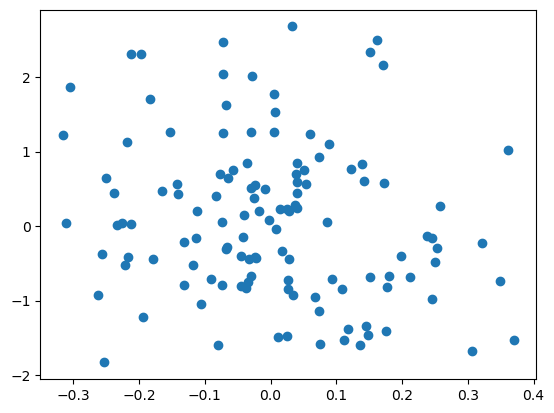

In [16]:
plt.scatter(prec_mean_tai,nino34_cut)

In [17]:
from scipy.stats import linregress

In [18]:
slope, intercept, r_value, p_value, std_err = linregress(prec_mean_tai,nino34_cut)

In [19]:
slope,intercept,r_value,p_value, std_err

(-1.304797292253949,
 0.09101828205625755,
 -0.18899776694596587,
 0.03629633924900323,
 0.6163043501760999)

In [21]:
r_sq = r_value**2
r_sq

0.03572015591056163

Text(0.5, 1.0, 'Regression between  Winter precipitation in Taiwan and Nino3.4 ')

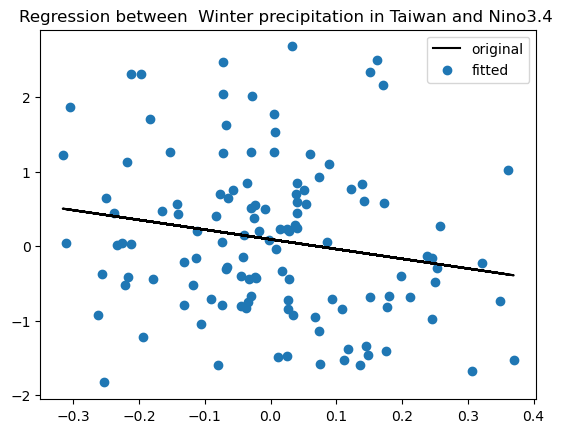

In [20]:
plt.scatter(prec_mean_tai,nino34_cut)
plt.plot(prec_mean_tai, intercept + slope*prec_mean_tai, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between  Winter precipitation in Taiwan and Nino3.4 ")

In [23]:
slope, intercept, r_value, p_value, std_err = linregress(prec_mean_Mel,nino34_cut)

In [24]:
slope,intercept,r_value,p_value, std_err

(-0.476786268522338,
 0.0910182886877319,
 -0.03313211338374516,
 0.7160066374763685,
 1.3075051665738122)

In [25]:
r_sq = r_value**2
r_sq

0.001097736937273345

Text(0.5, 1.0, 'Regression between precipitation in Melbourne and Nino3.4 ')

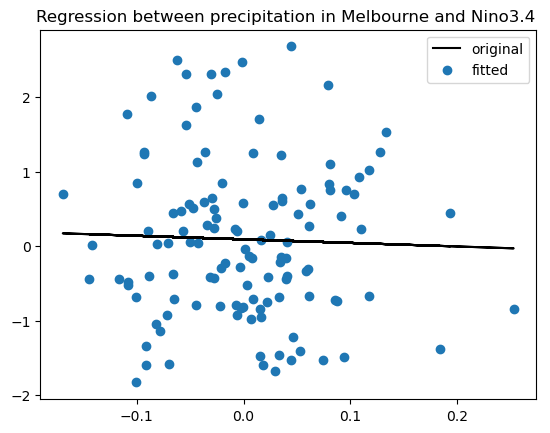

In [27]:
plt.scatter(prec_mean_Mel,nino34_cut)
plt.plot(prec_mean_Mel, intercept + slope*prec_mean_Mel, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between precipitation in Melbourne and Nino3.4 ")

In [29]:
slope, intercept, r_value, p_value, std_err = linregress(prec_mean_tai_de,nino34_cut)

In [30]:
slope,intercept,r_value,p_value, std_err

(-1.2554223427442988,
 0.09101827966981346,
 -0.17259621570783587,
 0.05626309451246619,
 0.6513267194710108)

In [31]:
r_sq = r_value**2
r_sq

0.02978945367666581

Text(0.5, 1.0, 'Regression between Detrended Precipitation in Taiwan and Nino3.4 ')

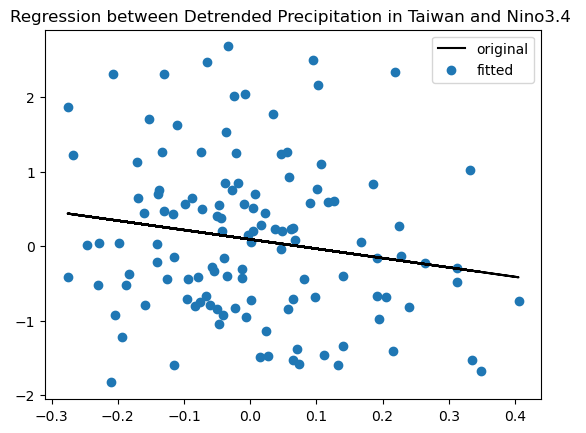

In [33]:
plt.scatter(prec_mean_tai_de,nino34_cut)
plt.plot(prec_mean_tai_de, intercept + slope*prec_mean_tai_de, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Detrended Precipitation in Taiwan and Nino3.4 ")

In [34]:
slope, intercept, r_value, p_value, std_err = linregress(prec_mean_mel_de,nino34_cut)

In [35]:
slope,intercept,r_value,p_value, std_err

(-0.1089211261370089,
 0.09101828875691442,
 -0.007145090004747371,
 0.9374822139426477,
 1.3858002894491404)

In [36]:
r_sq = r_value**2
r_sq

5.105231117594078e-05

Text(0.5, 1.0, 'Regression between Detrended Precipitation in Melbourne and Nino3.4 ')

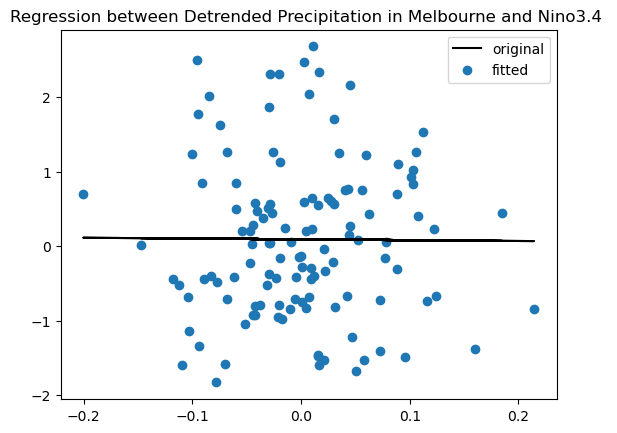

In [37]:
plt.scatter(prec_mean_mel_de,nino34_cut)
plt.plot(prec_mean_mel_de, intercept + slope*prec_mean_mel_de, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Detrended Precipitation in Melbourne and Nino3.4 ")

In [40]:
#select month 
temp2 = temp.sel(time = temp.time.dt.month.isin([1, 2, 12])) #winter half year
temp2

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 123)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Data variables:
    air      (time, lat, lon) float32 -34.91 -34.91 -34.91 ... -22.48 -22.48
Attributes:
    description:    Data from NCEP initialized reanalysis (4x/day).  These ar...
    platform:       Model
    Conventions:    COARDS
    NCO:            20121012
    history:        Thu May  4 20:11:16 2000: ncrcat -d time,0,623 /Datasets/...
    title:          monthly mean air.sig995 from the NCEP Reanalysis
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

In [42]:
# make precipitation anomaly

temp_clim = temp2.air.groupby('time.month').mean(dim = 'time')
temp_anom = temp2.air.groupby('time.month') - temp_clim

In [43]:
# make precipitation detrend
from scipy.signal import detrend
temp_anom_detrended = xr.apply_ufunc(detrend, temp_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~temp_anom.isnull())

In [44]:
# raw data: select domain of Taiwan
temp_anom_tai = temp_anom.sel(lat=slice(23.5), lon=slice(120))
temp_mean_tai = temp_anom_tai.mean(dim=('lon', 'lat'))
temp_mean_tai

<xarray.DataArray 'air' (time: 123)>
array([-3.5083492e+00, -3.9811420e+00,  3.1976633e-02, -1.5929037e+00,
       -8.8098717e-01, -8.6688709e-01, -4.1168803e-01, -1.8855985e-01,
       -6.5948558e-01, -1.9734216e+00, -1.3777697e+00,  4.3815279e-01,
        6.2154520e-01, -8.5027987e-01, -5.9783274e-01,  1.3993828e+00,
        2.3182444e-01, -1.0237995e+00, -1.1743320e+00, -1.6059749e+00,
       -4.5191127e-01, -1.0355344e+00, -2.2706580e+00, -1.7304879e+00,
       -1.4498538e+00, -1.0693121e+00, -1.0093861e+00, -1.7598931e-01,
       -5.3595924e-01,  5.3339373e-02, -1.2327520e+00,  1.7257310e-03,
       -1.2169838e-01,  5.4679263e-01,  2.4269910e+00, -8.3839798e-01,
        6.7475331e-01, -1.4372773e+00, -7.1637440e-01, -8.3567187e-02,
       -4.0616151e-02, -4.5171469e-01, -1.8508552e-01, -6.7680374e-02,
       -1.4876657e+00, -9.5487714e-01, -2.5010564e+00, -6.4499891e-01,
       -7.4681684e-02,  2.5963604e+00, -1.9670633e+00, -1.3331422e+00,
       -1.1528296e+00, -1.4199612e+00, -2.1001794e+00, -1.0412828e+00,
       -1.5400064e+00, -2.1201828e-01, -1.4070721e+00, -3.0800092e-01,
       -1.0723964e-02,  1.3851838e+00,  1.9921085e+00, -1.9091269e-01,
        9.5840299e-01, -1.8321486e-01,  3.2090750e-01,  4.3123695e-01,
        1.8528220e-01,  9.3057966e-01,  1.1758388e+00, -1.9365234e+00,
       -3.1064206e-01, -1.1803470e+00,  1.4474490e-01, -1.2438340e-01,
        6.7538746e-02,  5.6482100e-01,  2.4233110e+00,  4.1804045e-01,
        1.4511420e+00,  9.1202843e-01,  3.9639848e-01,  1.3698232e+00,
        2.3903363e+00,  1.3842833e-01,  1.0669259e+00, -5.1816893e-01,
        4.4258526e-01,  7.6073050e-01,  1.0604984e+00, -4.0158388e-01,
       -7.6154900e-01, -1.1063635e+00, -9.9064130e-01, -1.6046118e+00,
       -6.0291821e-01, -1.9540979e-01,  1.8105025e+00,  9.6593207e-01,
        4.0982041e-01, -1.0768040e+00,  5.7695395e-01, -2.0783265e-01,
        1.4500417e+00,  4.9895358e-01,  8.3789718e-01,  1.2888018e+00,
        6.6011119e-01,  1.8055493e+00,  2.4237943e+00,  2.5190229e+00,
        4.3161354e+00,  1.8327371e+00,  2.0046856e+00,  2.2691913e+00,
        2.0836403e+00,  1.6042737e+00,  2.6565907e+00,  7.9247069e-01,
        2.5242016e-01,  4.1852993e-01,  1.6573428e+00], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 12 1 2 12 1 2 12 1 2 ... 2 12 1 2 12 1 2 12 1 2 12

In [45]:
# raw data: select domain of Melbourne
temp_anom_Mel = temp_anom.sel(lat=slice(-35), lon=slice(147))
temp_mean_Mel = temp_anom_Mel.mean(dim=('lon', 'lat'))
temp_mean_Mel

<xarray.DataArray 'air' (time: 123)>
array([-1.7623565 , -1.9804665 ,  0.05267433, -0.64037573, -0.47604898,
       -0.31122088, -0.20680878, -0.20187233, -0.4266987 , -1.138329  ,
       -0.7558933 ,  0.12344352,  0.13971372, -0.43420413, -0.37999082,
        0.49823397, -0.11579475, -0.6779302 , -0.5678642 , -0.6945839 ,
       -0.37022737, -0.771313  , -1.1347967 , -0.8686679 , -0.73191196,
       -0.60225874, -0.5298777 ,  0.11739776, -0.15848972,  0.01551299,
       -0.78486264, -0.08029253, -0.03384047,  0.12819389,  1.0737506 ,
       -0.2687629 ,  0.47311175, -0.7123983 , -0.48915255, -0.3304919 ,
       -0.1972709 , -0.5216573 , -0.3354987 , -0.37852532, -1.049995  ,
       -0.65585786, -1.3117062 , -0.4872332 , -0.06425054,  1.303186  ,
       -1.0600973 , -0.7878887 , -0.62143403, -0.9377678 , -1.1526988 ,
       -0.8489609 , -0.6156658 ,  0.09567151, -0.29347283, -0.28587377,
        0.06355101,  0.6483383 ,  0.8205973 , -0.02303546,  0.33133274,
       -0.17811778,  0.06129366, -0.02806788,  0.16052994,  0.43104124,
        0.46713093, -0.76204896, -0.04693956, -0.42206535,  0.26735592,
        0.08604873, -0.00396218,  0.272576  ,  1.2122046 ,  0.46382728,
        0.7265173 ,  0.5784732 ,  0.34156775,  0.72599626,  1.1990575 ,
        0.35365626,  0.6523265 , -0.29894465, -0.00798642,  0.39533377,
        0.7294408 , -0.11013325, -0.13535441, -0.30420166, -0.11801647,
       -0.67283785, -0.24191421, -0.03165087,  0.7618658 ,  0.44901776,
        0.20494236, -0.42259857,  0.3374312 , -0.10690153,  0.8600615 ,
        0.14746755,  0.33018968,  0.6498963 ,  0.3245142 ,  1.1338956 ,
        1.3177756 ,  1.5376345 ,  2.1851013 ,  1.06675   ,  1.1652038 ,
        1.1294436 ,  0.9332778 ,  0.6665554 ,  1.3998421 ,  0.6073954 ,
        0.40428507,  0.46104708,  1.0757343 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 12 1 2 12 1 2 12 1 2 ... 2 12 1 2 12 1 2 12 1 2 12

In [46]:
# detrend data: select domain of Taiwan
temp_anom_tai_de = temp_anom_detrended.sel(lat=slice(23.5), lon=slice(120))
temp_mean_tai_de = temp_anom_tai_de.mean(dim=('lon', 'lat'))
temp_mean_tai_de

<xarray.DataArray 'air' (time: 123)>
array([-2.1954558 , -2.6897712 ,  1.3018247 , -0.34457862,  0.34581524,
        0.33839247,  0.77206874,  0.97367394,  0.48122543, -0.85423344,
       -0.28010446,  1.5142953 ,  1.6761647 ,  0.18281688,  0.41374123,
        2.389434  ,  1.2003525 , -0.07679441, -0.24884965, -0.70201546,
        0.4305256 , -0.17462054, -1.4312669 , -0.9126196 , -0.65350837,
       -0.2944895 , -0.25608644,  0.5557874 ,  0.17429468,  0.74207044,
       -0.5655438 ,  0.64741105,  0.5024641 ,  1.1494323 ,  3.008108  ,
       -0.27880403,  1.2128245 , -0.9207289 , -0.22134896,  0.38993552,
        0.41136357, -0.02125776,  0.22384834,  0.31973088, -1.1217774 ,
       -0.6105116 , -2.178214  , -0.3436791 ,  0.20511524,  2.8546348 ,
       -1.7303119 , -1.1179138 , -0.95912415, -1.2477788 , -1.9495195 ,
       -0.9121459 , -1.4323924 , -0.12592699, -1.3425037 , -0.2649553 ,
        0.0107987 ,  1.3851836 ,  1.9705856 , -0.23395853,  0.89383423,
       -0.26930645,  0.21329305,  0.30209965,  0.03462207,  0.75839674,
        0.9821331 , -2.1517522 , -0.5473934 , -1.4386213 , -0.1350524 ,
       -0.42570344, -0.2553041 ,  0.22045527,  2.0574224 ,  0.03062931,
        1.0422076 ,  0.481571  , -0.0555816 ,  0.89632034,  1.8953109 ,
       -0.3781202 ,  0.52885455, -1.0777631 , -0.13853192,  0.15809052,
        0.4363356 , -1.0472696 , -1.4287574 , -1.795095  , -1.7008954 ,
       -2.3363886 , -1.3562182 , -0.97023255,  1.014157  ,  0.14806345,
       -0.4295708 , -1.9377182 , -0.30548298, -1.1117926 ,  0.5245589 ,
       -0.44805193, -0.13063128,  0.2987505 , -0.3514629 ,  0.7724525 ,
        1.3691742 ,  1.44288   ,  3.2184696 ,  0.7135485 ,  0.8639744 ,
        1.1069571 ,  0.8998835 ,  0.39899406,  1.4297881 , -0.4558549 ,
       -1.017428  , -0.8728413 ,  0.3444489 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 12 1 2 12 1 2 12 1 2 ... 2 12 1 2 12 1 2 12 1 2 12

In [47]:
# detrend data: select domain of Taiwan
temp_anom_mel_de = temp_anom_detrended.sel(lat=slice(-35), lon=slice(147))
temp_mean_mel_de = temp_anom_mel_de.mean(dim=('lon', 'lat'))
temp_mean_mel_de

<xarray.DataArray 'air' (time: 123)>
array([-1.00089180e+00, -1.23148513e+00,  7.89172947e-01,  8.36397633e-02,
        2.35483527e-01,  3.87828618e-01,  4.79757696e-01,  4.72211123e-01,
        2.34901741e-01, -4.89211679e-01, -1.19258903e-01,  7.47594833e-01,
        7.51381993e-01,  1.64981157e-01,  2.06711456e-01,  1.07245326e+00,
        4.45941389e-01, -1.28677085e-01, -3.10939532e-02, -1.70296848e-01,
        1.41576707e-01, -2.71991998e-01, -6.47958875e-01, -3.94312948e-01,
       -2.70040065e-01, -1.52869806e-01, -9.29718539e-02,  5.41820586e-01,
        2.53450096e-01,  4.14969772e-01, -3.97888839e-01,  2.94198185e-01,
        3.28167260e-01,  4.77718651e-01,  1.41079235e+00,  5.57957590e-02,
        7.85187304e-01, -4.12805736e-01, -2.02042997e-01, -5.58653437e-02,
        6.48726225e-02, -2.71996766e-01, -9.83212069e-02, -1.53830901e-01,
       -8.37783635e-01, -4.56129551e-01, -1.12446082e+00, -3.12470824e-01,
        9.80287418e-02,  1.45298219e+00, -9.22784209e-01, -6.63058519e-01,
       -5.09086907e-01, -8.37903678e-01, -1.06531775e+00, -7.74062812e-01,
       -5.53250790e-01,  1.45603552e-01, -2.56023765e-01, -2.60907859e-01,
        7.60339424e-02,  6.48338258e-01,  8.08114231e-01, -4.80015837e-02,
        2.93883562e-01, -2.28049979e-01, -1.12156919e-03, -1.02966145e-01,
        7.31486902e-02,  3.31176966e-01,  3.54783595e-01, -8.86879265e-01,
       -1.84252903e-01, -5.71861744e-01,  1.05076432e-01, -8.87137204e-02,
       -1.91207707e-01,  7.28474557e-02,  9.99993026e-01,  2.39132717e-01,
        4.89339769e-01,  3.28812599e-01,  7.94240385e-02,  4.51369673e-01,
        9.11947846e-01,  5.40635176e-02,  3.40250701e-01, -6.23503327e-01,
       -3.45028311e-01,  4.58088592e-02,  3.67432952e-01, -4.84624207e-01,
       -5.22328377e-01, -7.03658581e-01, -5.29956460e-01, -1.09726083e+00,
       -6.78820372e-01, -4.81039941e-01,  2.99993604e-01, -2.53373794e-02,
       -2.81895995e-01, -9.21919882e-01, -1.74373001e-01, -6.31188750e-01,
        3.23291153e-01, -4.01785761e-01, -2.31546670e-01,  7.56769925e-02,
       -2.62188166e-01,  5.34710169e-01,  7.06107199e-01,  9.13483083e-01,
        1.54846656e+00,  4.17632520e-01,  5.03603280e-01,  4.55360085e-01,
        2.46711180e-01, -3.24941911e-02,  6.88309610e-01, -1.16620392e-01,
       -3.32213670e-01, -2.87934691e-01,  3.14269483e-01], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 12 1 2 12 1 2 12 1 2 ... 2 12 1 2 12 1 2 12 1 2 12

In [49]:
slope, intercept, r_value, p_value, std_err = linregress(temp_mean_tai,nino34_cut)

In [50]:
slope,intercept,r_value,p_value, std_err

(0.004978484662556141,
 0.09101828934209662,
 0.006409419736596042,
 0.9439080639873851,
 0.07061173038176116)

In [51]:
r_sq = r_value**2
r_sq

4.108066135986688e-05

Text(0.5, 1.0, 'Regression between Precipitation in Taiwan and Nino3.4 ')

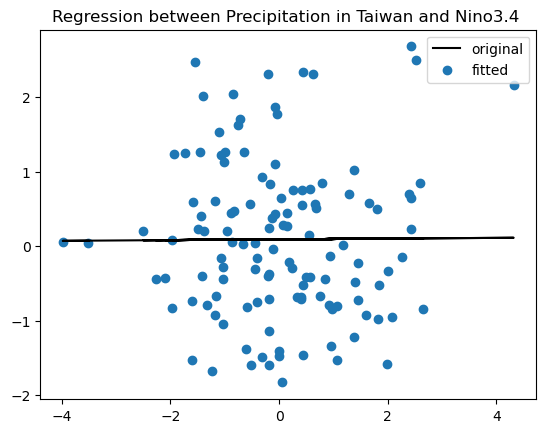

In [53]:
plt.scatter(temp_mean_tai,nino34_cut)
plt.plot(temp_mean_tai, intercept + slope*temp_mean_tai, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Precipitation in Taiwan and Nino3.4 ")

In [54]:
slope, intercept, r_value, p_value, std_err = linregress(temp_mean_Mel,nino34_cut)

In [55]:
slope,intercept,r_value,p_value, std_err

(0.0974145322291141,
 0.09101828838349815,
 0.06528097583516522,
 0.4731431129931021,
 0.1353683243831617)

In [56]:
r_sq = r_value**2
r_sq

0.004261605805991425

Text(0.5, 1.0, 'Regression between Precipitation in Melbourne and Nino3.4 ')

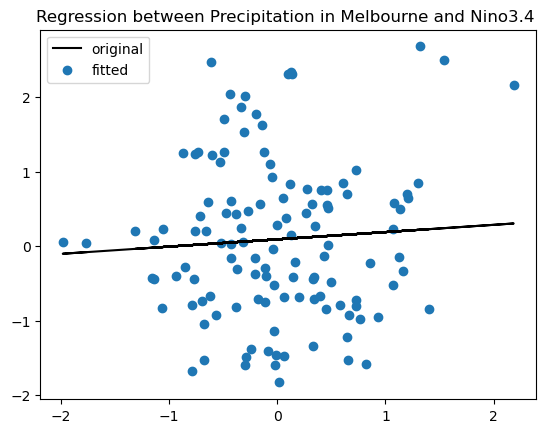

In [58]:
plt.scatter(temp_mean_Mel,nino34_cut)
plt.plot(temp_mean_Mel, intercept + slope*temp_mean_Mel, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Precipitation in Melbourne and Nino3.4 ")

In [59]:
slope, intercept, r_value, p_value, std_err = linregress(temp_mean_tai_de,nino34_cut)

In [60]:
slope,intercept,r_value,p_value, std_err

(0.058894626879112885,
 0.09101829684785465,
 0.0625526324175068,
 0.49187329984228123,
 0.08542521319439648)

In [61]:
r_sq = r_value**2
r_sq

0.003912831822359723

Text(0.5, 1.0, 'Regression between Detrended Precipitation in Taiwan and Nino3.4 ')

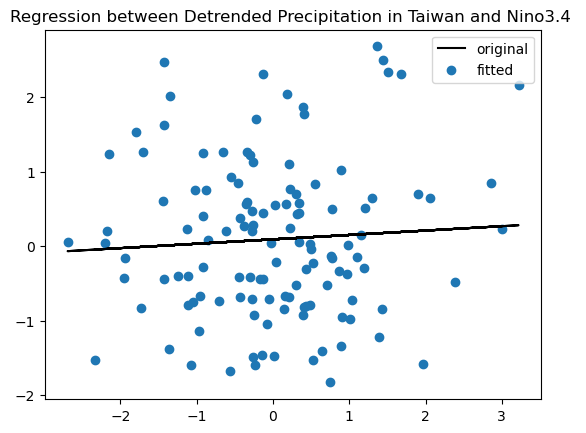

In [62]:
plt.scatter(temp_mean_tai_de,nino34_cut)
plt.plot(temp_mean_tai_de, intercept + slope*temp_mean_tai_de, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Detrended Precipitation in Taiwan and Nino3.4 ")

In [63]:
slope, intercept, r_value, p_value, std_err = linregress(temp_mean_mel_de,nino34_cut)

In [64]:
slope,intercept,r_value,p_value, std_err

(0.2859522983789709,
 0.09101831427018571,
 0.14886146121123814,
 0.10032794040533773,
 0.1726841936815319)

In [65]:
r_sq = r_value**2
r_sq

0.022159734633944956

Text(0.5, 1.0, 'Regression between Detrended Precipitation in Melbourne and Nino3.4 ')

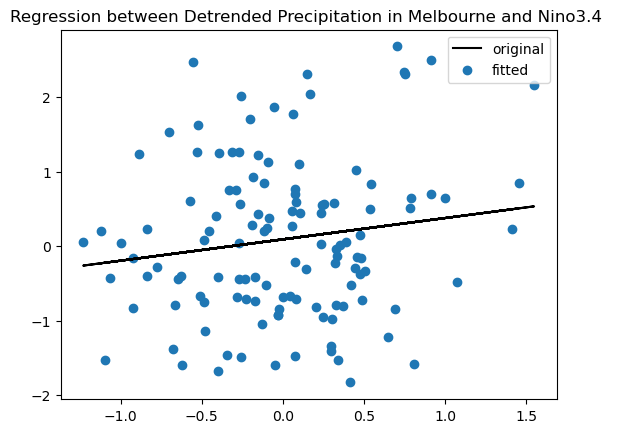

In [66]:
plt.scatter(temp_mean_mel_de,nino34_cut)
plt.plot(temp_mean_mel_de, intercept + slope*temp_mean_mel_de, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Detrended Precipitation in Melbourne and Nino3.4 ")